# Backtesting Framework Adapters

This notebook summarizes how De-Time signals can be routed into existing Python backtesting and reporting frameworks. The transparent pandas backtester should be used first to verify alignment and costs.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ"], start="2018-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
entries, exits = turtle_donchian_signals(prices, features)
pandas_result = backtest_long_short_signals(prices, entries, exits)
pandas_result.stats_frame()

,value
total_return,0.664135
cagr,0.062746
volatility,0.094077
sharpe,0.694118
max_drawdown,-0.141222
calmar,0.444307
hit_rate,0.255571
average_turnover,0.030820
average_gross_exposure,0.457089
fee_bps,5.000000


## Visualization: pandas baseline diagnostics

The pandas baseline now shows both risk and signal density before optional framework adapters are introduced.

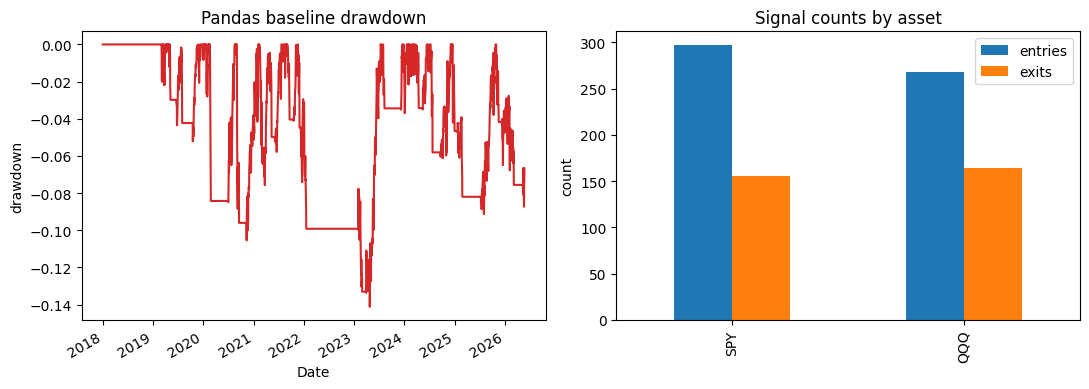

In [3]:
drawdown = pandas_result.equity / pandas_result.equity.cummax() - 1.0
signal_counts = pd.DataFrame({"entries": entries.sum(), "exits": exits.sum()})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
drawdown.plot(ax=axes[0], color="tab:red", title="Pandas baseline drawdown")
signal_counts.plot(kind="bar", ax=axes[1], title="Signal counts by asset")
axes[0].set_ylabel("drawdown")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


In [4]:
from quant_trading.frameworks import (
    run_vectorbt_from_signals,
    run_bt_target_weights,
    run_backtestingpy_signal,
    write_framework_templates,
    quantstats_html_report,
)

template_paths = write_framework_templates(ROOT / "examples" / "quant_trading" / "templates")
pd.DataFrame({"template": [path.relative_to(ROOT).as_posix() for path in template_paths]})

,template
0,examples/quant_trading/templates/backtrader_de...
1,examples/quant_trading/templates/zipline_reloa...


In [5]:
# Optional examples after installing the relevant packages:
# vectorbt_portfolio = run_vectorbt_from_signals(prices, entries, exits)
# quantstats_html_report(pandas_result.returns, ROOT / "examples" / "quant_trading" / "reports" / "tear_sheet.html")